Diabetes prediction using Logistic Regression

Importing dependencies

In [469]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

Data Collection

In [430]:
diabetes_data = pd.read_csv("diabetes_prediction_dataset.csv")


In [431]:
diabetes_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Data Analysis and Visualization

In [432]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [433]:
diabetes_data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [434]:
diabetes_data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Bar graph for gender vs heart disease

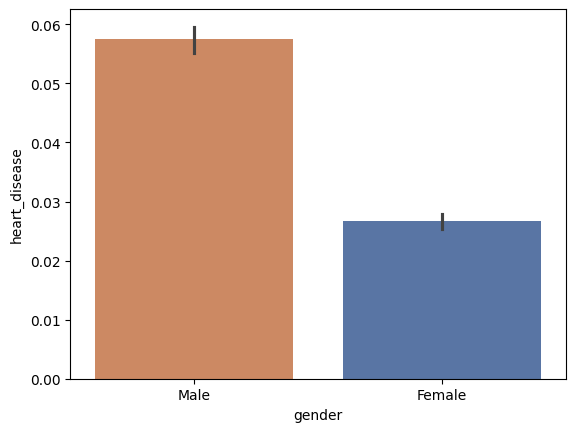

In [435]:
sns.barplot(x="gender",y="heart_disease" ,order=["Male" ,"Female"], data=diabetes_data , palette="deep" , hue="gender")
plt.show()

Plotting a bar graph for age vs hypertension

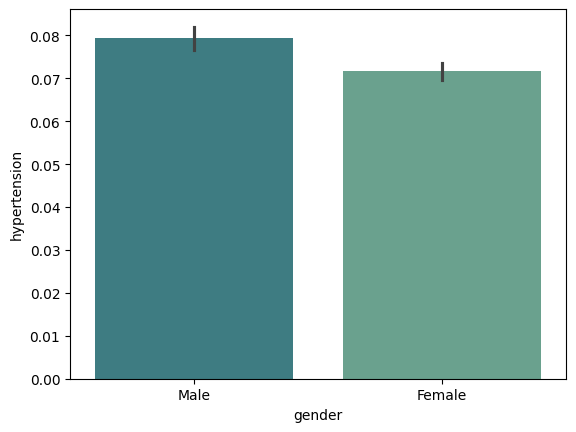

In [436]:
sns.barplot(x="gender" , y="hypertension", order=['Male',"Female"] ,data=diabetes_data, palette="crest", hue="gender")
plt.show()

Changing-> Male to 0 & Female to 1
Changing->
never to 0,
No Info to 3,
current to 1,
not current to 2

In [437]:
diabetes_data["gender"] = diabetes_data["gender"].map({"Male":0 , "Female":1 , "Other":2})

In [438]:
diabetes_data["smoking_history"] = diabetes_data["smoking_history"].map({"never":0 ,"ever":4 ,"No Info":3 ,"current":1 ,"not current":2,"former":3})

In [439]:
diabetes_data.head(100)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,80.0,0,1,0,25.19,6.6,140,0
1,1,54.0,0,0,3,27.32,6.6,80,0
2,0,28.0,0,0,0,27.32,5.7,158,0
3,1,36.0,0,0,1,23.45,5.0,155,0
4,0,76.0,1,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
95,0,19.0,0,0,0,27.32,6.1,80,0
96,1,67.0,0,0,0,27.32,6.2,159,1
97,0,11.0,0,0,3,27.32,6.1,90,0
98,1,30.0,0,0,3,50.13,6.0,100,0


Heatmap for understanding correlation between columns

In [440]:
correlation = diabetes_data.corr()

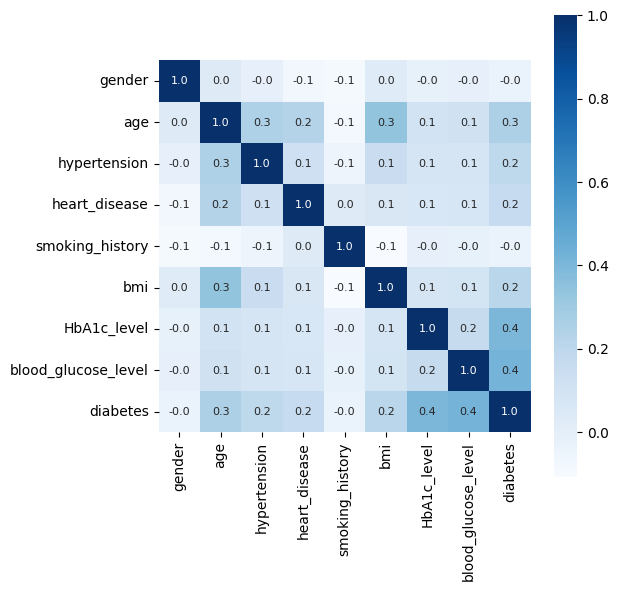

In [441]:
plt.figure(figsize=(6,6))
sns.heatmap(correlation , cbar=True, square=True , fmt='.1f' , annot=True , annot_kws={'size':8}, cmap='Blues')
plt.show()

Separating features and labels

In [442]:
x = diabetes_data.drop(columns="diabetes" , axis=1)

In [443]:
y = diabetes_data["diabetes"]

In [444]:
print(x)

       gender   age  hypertension  ...    bmi  HbA1c_level  blood_glucose_level
0           1  80.0             0  ...  25.19          6.6                  140
1           1  54.0             0  ...  27.32          6.6                   80
2           0  28.0             0  ...  27.32          5.7                  158
3           1  36.0             0  ...  23.45          5.0                  155
4           0  76.0             1  ...  20.14          4.8                  155
...       ...   ...           ...  ...    ...          ...                  ...
99995       1  80.0             0  ...  27.32          6.2                   90
99996       1   2.0             0  ...  17.37          6.5                  100
99997       0  66.0             0  ...  27.83          5.7                  155
99998       1  24.0             0  ...  35.42          4.0                  100
99999       1  57.0             0  ...  22.43          6.6                   90

[100000 rows x 8 columns]


In [445]:
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 100000, dtype: int64


Splitting data into training data and test data

In [446]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [447]:
print(x.shape , x_train.shape , x_test.shape)

(100000, 8) (80000, 8) (20000, 8)


Model Training

In [450]:
model = LogisticRegression()

In [452]:
model.fit(x_train,y_train)

c:\Users\Rajasekar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Model Evaluation using accuracy score , classification report 

In [454]:
x_train_prediction = model.predict(x_train)

In [459]:
training_data_accuracy = accuracy_score(y_train , x_train_prediction)

print("Training data accuracy :",training_data_accuracy)


Training data accuracy : 0.9403875


In [460]:
x_test_prediction = model.predict(x_test)

In [461]:
test_data_accuracy = accuracy_score(y_test , x_test_prediction)

print("Test data accuracy :",test_data_accuracy)

Test data accuracy : 0.9385


In [470]:
print(classification_report(y_test , x_test_prediction))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97     18292
           1       0.72      0.45      0.56      1708

    accuracy                           0.94     20000
   macro avg       0.84      0.72      0.76     20000
weighted avg       0.93      0.94      0.93     20000



Building a predictive system

In [468]:
input_data = (1,22.0,0,0,0,24.59,4.5,126)

input_df = pd.DataFrame([input_data] ,columns=x.columns)

prediction = model.predict(input_df)

if (prediction==0):
    print("The person doesn't have diabetes")
else:
    print("The person has diabetes")

The person doesn't have diabetes
